# Pizza vs. Steak — Student Starter Notebook

**Goal:** Build a binary image classifier (**pizza** vs **steak**) using only images from `pizza_steak/train/`.

**Your tasks**
1. **Implement your model** inside `build_model()` — input images are provided by the fixed pipeline.
2. **Compile and train** your model on the provided `train_ds` and `val_ds`.
3. **Export** your final model as `student_model.keras` and create a model diagram image (e.g., `student_model.png`).

**Rules**
- Do **not** modify the fixed cells (data loading/split/pipeline).
- You may use transfer learning (e.g., `tf.keras.applications`).
- Ensure your model outputs a value suitable for **binary classification** and is **compiled** before training.

## 0. Imports (fixed)

In [1]:
import tensorflow as tf
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


## 1. Data paths (fixed)

In [2]:
DATA_ROOT = Path('pizza_steak')
TRAIN_DIR = DATA_ROOT / 'train'

classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
assert set(classes) == {'pizza', 'steak'}, f"Expected classes ['pizza','steak'], got: {classes}"
print('Classes:', classes)

Classes: ['pizza', 'steak']


## 2. File listing + split (fixed)

In [3]:
paths, labels = [], []

for cls in classes:
    for p in (TRAIN_DIR / cls).glob('*.jpg'):
        paths.append(str(p))
        labels.append(cls)

assert len(paths) > 0, 'No training images found.'

df = pd.DataFrame({'path': paths, 'label': labels})
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=SEED
)
print('Train size:', len(train_df), 'Val size:', len(val_df))

Train size: 1200 Val size: 300


## 3. tf.data pipelines (fixed)

> **Augmentation:** Applied once in the **`tf.data`** pipeline below (training dataset only). Please **do not** add extra augmentation layers inside your model.

In [50]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
label_to_idx = {c: i for i, c in enumerate(classes)}

@tf.function
def _decode_img(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, tf.cast(label, tf.int32)

@tf.function
def _augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label

def make_ds(df, training=False):
    paths = df['path'].values
    labels = df['label'].map(label_to_idx).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_decode_img, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df, training=True)
val_ds   = make_ds(val_df, training=False)

for imgs, ys in train_ds.take(1):
    print('Sample batch:', imgs.shape, ys.shape)

Sample batch: (32, 224, 224, 3) (32,)


### Optional: preview one image and its label

Run the cell below to display a **random example** from the **validation** dataset (no augmentation).

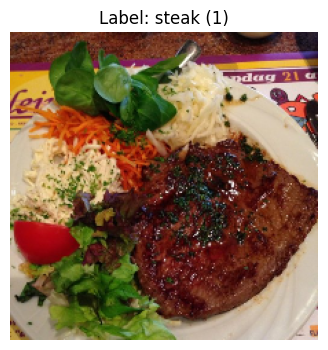

In [5]:
# Shows one random image + label from the *validation* dataset (no augmentation).
import numpy as np
import matplotlib.pyplot as plt

label_to_name = {v: k for k, v in label_to_idx.items()}

# Take one batch from validation, pick a random index
imgs, ys = next(iter(val_ds))
i = np.random.randint(len(ys))
img = imgs[i].numpy()
label_int = int(ys[i].numpy())

plt.figure(figsize=(4, 4))
plt.imshow(img)  # already in [0,1]
plt.axis('off')
plt.title(f"Label: {label_to_name[label_int]} ({label_int})")
plt.show()

## 4. Build your model (EDIT THIS CODE BLOCK)

- Return a **compiled** model.
- **Input images** come as `(224, 224, 3)` tensors from the pipeline.
- Use any compatible architecture; ensure the output suits **binary classification**.

In [ ]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224,224,3)),
        tf.keras.layers.Conv2D(2,3,activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=15, verbose = 1)
    loss, acc = model.evaluate(val_ds)
    print("Final val accuracy:", acc)
    return model

model = build_model()
tot_parms = model.count_params()
print(tot_parms)
model.summary()

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.5442 - loss: 0.7262 - val_accuracy: 0.5400 - val_loss: 0.6921
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5608 - loss: 0.7148 - val_accuracy: 0.5433 - val_loss: 0.6886
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5758 - loss: 0.6870 - val_accuracy: 0.5333 - val_loss: 0.6896
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5800 - loss: 0.6854 - val_accuracy: 0.5433 - val_loss: 0.6868
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6117 - loss: 0.6691 - val_accuracy: 0.5633 - val_loss: 0.6844
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5792 - loss: 0.6774 - val_accuracy: 0.5600 - val_loss: 0.6805
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6067 - loss: 0.6586 - val_accuracy: 0.5600 - val_loss: 0.6770
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6008 - loss: 0.6545 - val_accuracy: 0.5567 - v

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 222, 222, 2)    │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 222, 222, 2)    │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 111, 111, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 111, 111, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_16     │ (None, 2)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195 (784.00 B)

 Trainable params: 63 (252.00 B)

 Non-trainable params: 4 (16.00 B)

 Optimizer params: 128 (516.00 B)

## 5. Train, evaluate and export (CREATE NEW CODE BLOCK(S))

**You must:**
- Fit your model on `train_ds` and validate on `val_ds`.
- Save model (e.g. `student_model.keras`).
- Save a model diagram image (e.g. `student_model.png`).

In [39]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224,224,3)),
        tf.keras.layers.Conv2D(2,3,activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Dropout(0.6),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=15, verbose = 1)
    loss, acc = model.evaluate(val_ds)
    print("Final val accuracy:", acc)
    return model

model = build_model()
tot_parms = model.count_params()
print(tot_parms)
model.summary()

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.5033 - loss: 0.6960 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5092 - loss: 0.6940 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5292 - loss: 0.6906 - val_accuracy: 0.5267 - val_loss: 0.6928
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5375 - loss: 0.6903 - val_accuracy: 0.6700 - val_loss: 0.6925
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5283 - loss: 0.6883 - val_accuracy: 0.6567 - val_loss: 0.6917
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5792 - loss: 0.6829 - val_accuracy: 0.6333 - val_loss: 0.6908
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5742 - loss: 0.6849 - val_accuracy: 0.6267 - val_loss: 0.6895
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5792 - loss: 0.6795 - val_accuracy: 0.6467 - v

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 222, 222, 2)    │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 222, 222, 2)    │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 111, 111, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 111, 111, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_20     │ (None, 2)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195 (784.00 B)

 Trainable params: 63 (252.00 B)

 Non-trainable params: 4 (16.00 B)

 Optimizer params: 128 (516.00 B)

In [51]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224,224,3)),
        tf.keras.layers.Conv2D(2,3,activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=10, verbose = 1)
    loss, acc = model.evaluate(val_ds)
    print("Final val accuracy:", acc)
    return model

model = build_model()
tot_parms = model.count_params()
print(tot_parms)
model.summary()

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5592 - loss: 0.6915 - val_accuracy: 0.5000 - val_loss: 0.6813
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5642 - loss: 0.6924 - val_accuracy: 0.5500 - val_loss: 0.6750
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5658 - loss: 0.6795 - val_accuracy: 0.5933 - val_loss: 0.6684
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5708 - loss: 0.6887 - val_accuracy: 0.5900 - val_loss: 0.6658
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5817 - loss: 0.6815 - val_accuracy: 0.5967 - val_loss: 0.6708
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5800 - loss: 0.6832 - val_accuracy: 0.5267 - val_loss: 0.7099
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5992 - loss: 0.6665 - val_accuracy: 0.5567 - val_loss: 0.6811
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6017 - loss: 0.6450 - val_accuracy: 0.5633 - v

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ (None, 222, 222, 2)    │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 222, 222, 2)    │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 111, 111, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 111, 111, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_28     │ (None, 2)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195 (784.00 B)

 Trainable params: 63 (252.00 B)

 Non-trainable params: 4 (16.00 B)

 Optimizer params: 128 (516.00 B)

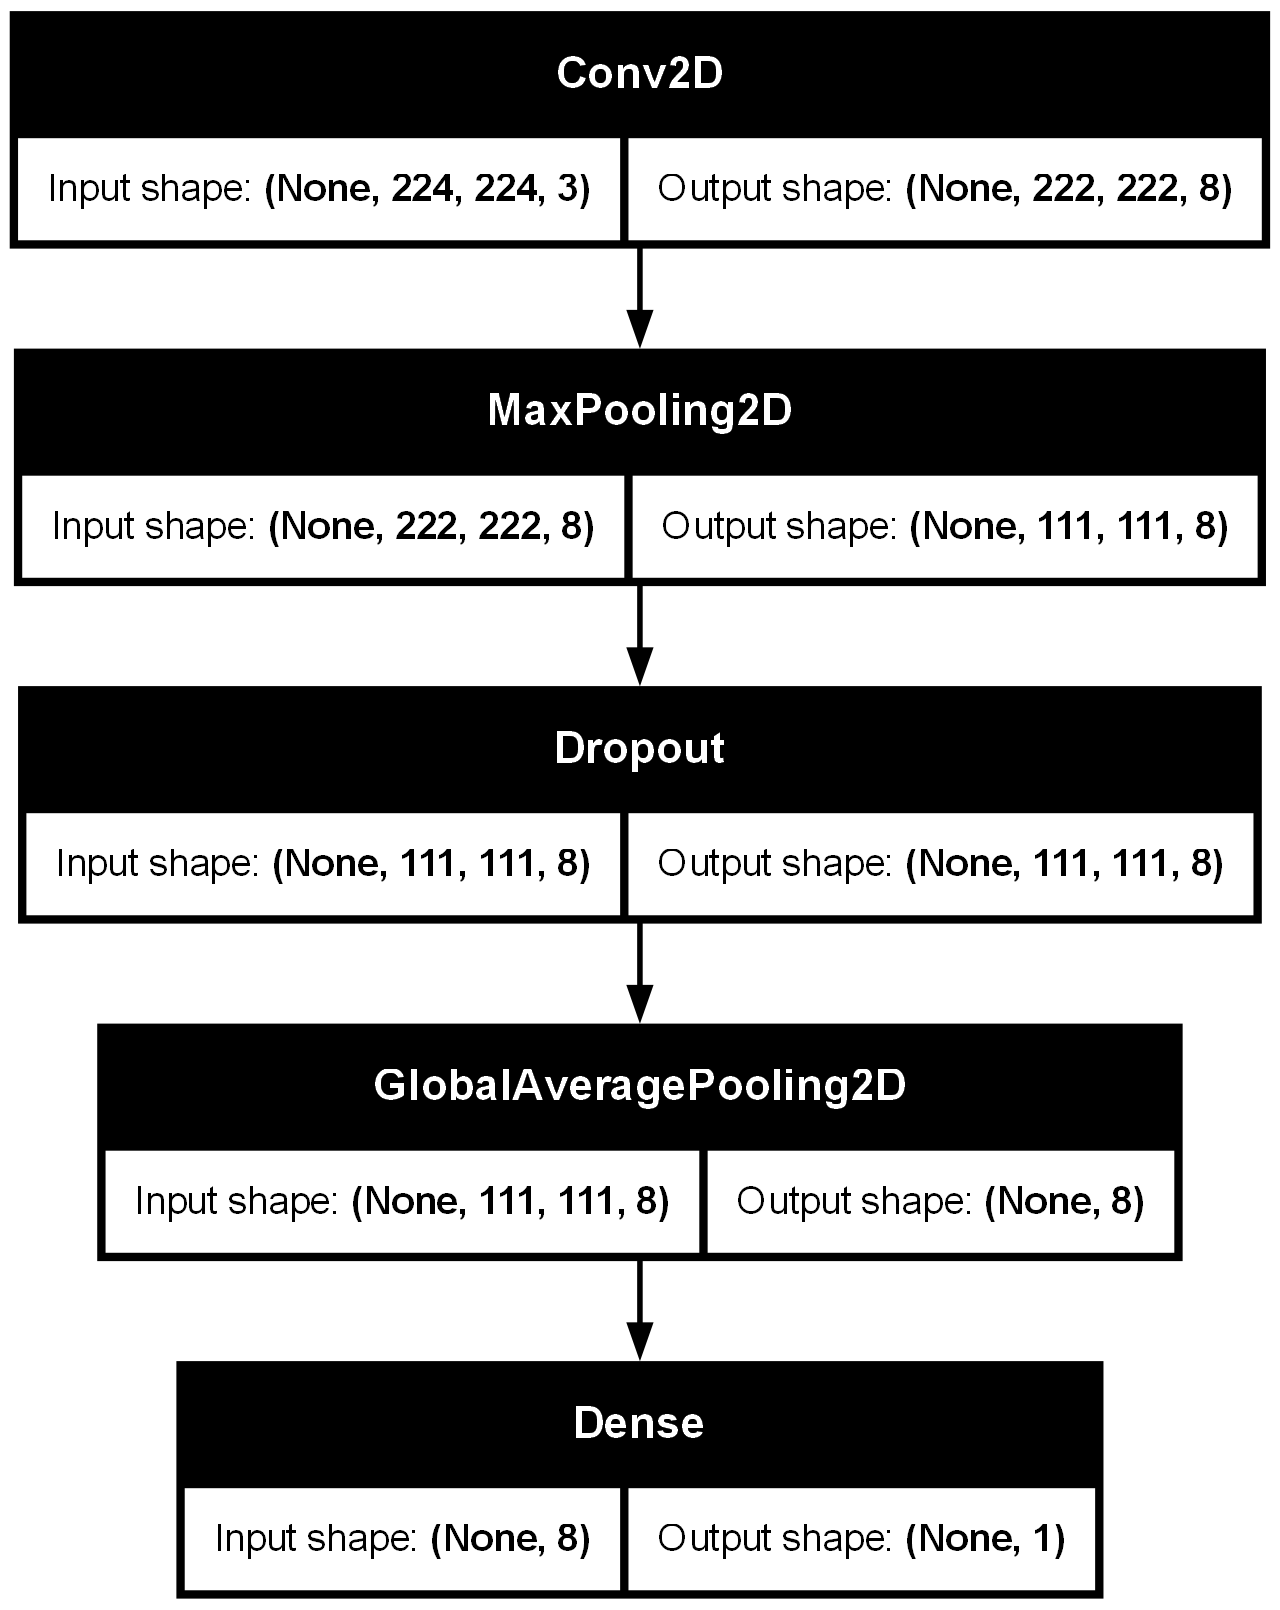

In [7]:
# after fit
model.save('Uuniis_model.keras')
tf.keras.utils.plot_model(model, to_file='Uuniis_model.png', show_shapes=True)